In [2]:
import numpy as np
import matplotlib.pyplot as plt
from gen_catalyst_design.db import Database, load_data_from_db
from ase.io import read

100


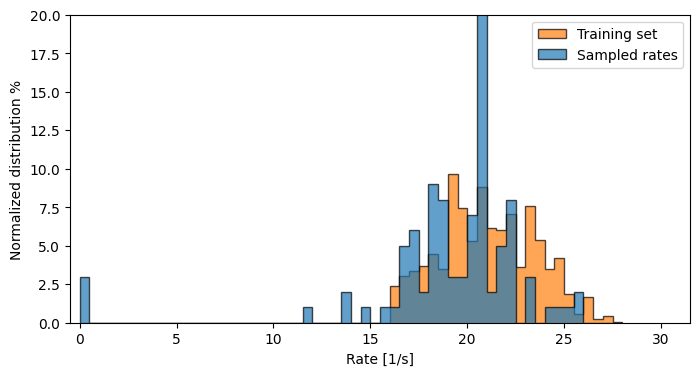

In [9]:
atoms_list = read(filename="../high_rate_structs.traj", index=":")
train_rates = np.array([atoms.info["rate"] for atoms in atoms_list])
element_pool = ["Rh", "Cu", "Pd", "Au"]

model = "model_005"
miller_index = "100"
database = Database.establish_connection(filename="rate_evals_0.db", miller_index=miller_index, pth_header=model)
datadicts = load_data_from_db(database=database)
print(len(datadicts))
sampled_rates = np.array([datadict["rate"] for datadict in datadicts])

fig, ax = plt.subplots(figsize=(8,4))
train_rates#rates = np.array([datadict["rate"] for datadict in datadicts])
rate_interval = 0.5
rate_max = np.max(train_rates)
rate_min = 0.0

i = 0
hist_prior = None
y_lims = 0.2*100
labels = [
    "Training set",
    "Sampled rates"
]

step = 2.5
classes = np.arange(1.0, np.ceil(rate_max)+step, step)#np.linspace(1.0, np.ceil(rate_max), 5)
for rates, color, label in zip([train_rates, sampled_rates], ["C1", "C0"], labels):
    bins = np.arange(rate_min, rate_max, rate_interval)
    hist, edges = np.histogram(rates, bins=bins)
    hist_norm = hist/np.sum(hist)
    ax.stairs(hist_norm*100, edges=edges, fill=True, alpha=0.7, edgecolor="k", linewidth=1, color=color, label=label)
    ax.set_xlim([-0.5, np.ceil(rate_max)+step])
    ax.set_ylim([0.0, y_lims])
    ax.set_ylabel("Normalized distribution %")
    ax.set_xlabel("Rate [1/s]")
ax.legend()

In [154]:
def get_avg_elem_stats(element_lists, element_pool):
    tot_atom_count = 0
    element_count = {}
    for element in element_pool:
        for element_list in element_lists:
            count = element_list.count(element)
            if element in element_count:
                element_count[element]+=count
            else:
                element_count[element]=count
            tot_atom_count+=count
    for element in element_count:
        element_count[element]/=tot_atom_count
    return element_count

In [155]:
train_element_lists = [atoms.get_chemical_symbols() for atoms in atoms_list]
train_stats = get_avg_elem_stats(element_lists=train_element_lists, element_pool=element_pool)

sample_element_lists = [datadict["elements"] for datadict in datadicts]
sample_stats = get_avg_elem_stats(element_lists=sample_element_lists, element_pool=element_pool)
print(train_stats)
print(np.array([train_stats[elem] for elem in train_stats]).sum())
print(sample_stats)
print(np.array([sample_stats[elem] for elem in sample_stats]).sum())


{'Rh': 0.1786360326074189, 'Cu': 0.4114689783165363, 'Pd': 0.40973054243897855, 'Au': 0.000164446637066272}
1.0
{'Rh': 0.0, 'Cu': 0.0, 'Pd': 0.0, 'Au': 1.0}
1.0


In [156]:
low_rate_indices = np.argwhere(train_rates < np.mean(train_rates)).squeeze()
high_rate_indices = np.argwhere(train_rates > np.mean(train_rates)).squeeze()
print(len(high_rate_indices))
for indices in [low_rate_indices, high_rate_indices]:
    filtered_atoms_list = [atoms_list[index] for index in indices]
    element_lists = [atoms.get_chemical_symbols() for atoms in filtered_atoms_list]
    element_stats = get_avg_elem_stats(element_lists=element_lists, element_pool=element_pool)
    print(element_stats)

765
{'Rh': 0.1862123613312203, 'Cu': 0.40819560787865067, 'Pd': 0.4053278997811486, 'Au': 0.0002641310089804543}
{'Rh': 0.16613756613756614, 'Cu': 0.41686896981014626, 'Pd': 0.4169934640522876, 'Au': 0.0}
